<a href="https://colab.research.google.com/github/sujithkumarmp/ai-colab/blob/main/langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LangChain is an open-source framework for building applications powered by large language models (LLMs), especially apps that need more than a single prompt/response.

In simple terms, it helps you connect an LLM to:

- Your data (files, databases, APIs)
- Tools (search, calculators, external services)
- Multi-step logic (chains, agents, workflows)
- Memory/context across interactions

Typical use cases:
- Chatbots over your own documents
- Retrieval-augmented generation (RAG)
- AI assistants that call tools/APIs
- Automated multi-step reasoning pipelines

In this *notebook*
- Agents — create_agent() API
- Models — init_chat_model() universal factory
- Messages — The 4 message types
- Tools — @tool decorator and dependency injection
- Short-term Memory — Checkpointers and thread isolation
- Streaming — Real-time output modes

# **Set Up**

In [1]:
# !pip install google-auth==2.47.0

In [2]:
%pip install -qU langchain google-genai langchain-tavily langgraph python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.6/760.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.1 which is incompatible.


In [3]:
%pip install -qU langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.8 MB/s eta 0:00:00


In [4]:
%pip install -qU langchain-community tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.1 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


**Code**

In [5]:
from google.colab import userdata
import google.generativeai as genai

# Retrieve the API key from Colab Secrets
api_key = userdata.get("GEMINI_API_KEY")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

def init_chat_model(model_name: str):
    return ChatGoogleGenerativeAI(model=model_name, google_api_key=api_key)

Now we can initialize our chat model using the `init_chat_model` factory.

In [7]:
model = init_chat_model("gemini-2-flash")

# **Gemini model

In [8]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

api_key = userdata.get("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)

text="why sky is blue?"
response = llm.invoke(text)
print(response.content)

The reason the sky appears blue is due to a phenomenon called **Rayleigh scattering**. Here's a breakdown:

1.  **Sunlight is White Light:** The light from the sun, which appears white to us, is actually made up of all the colors of the rainbow combined (a spectrum of visible light). Each color has a different wavelength: violet and blue have shorter wavelengths, while red and orange have longer wavelengths.

2.  **Earth's Atmosphere:** Our atmosphere is made of tiny gas molecules, primarily nitrogen (N2) and oxygen (O2), along with other gases and small particles. These molecules are much smaller than the wavelengths of visible light.

3.  **Rayleigh Scattering:** When sunlight enters the Earth's atmosphere, it collides with these tiny gas molecules. This causes the light to be scattered in all directions. The key to Rayleigh scattering is that **shorter wavelengths of light (like blue and violet) are scattered much more effectively than longer wavelengths (like red and orange).** In 

# Agent (LLM + Tool)

In [9]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

api_key = userdata.get("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)

agent = create_agent(model=model, tools=[add])
result = agent.invoke({"messages": "What is the capital of India and What is 12 + 27?"})
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

The capital of India is New Delhi and 12 + 27 = 39.


In [10]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

api_key = userdata.get("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)

agent = create_agent(model=model, tools=[add])
for chunk in agent.stream(
    {"messages": "What's the capital of France? and what is 45+33?"},
    stream_mode="values",
):
    print(chunk["messages"][-1].pretty_print())

================================ Human Message =================================

What's the capital of France? and what is 45+33?
None
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The capital of France is Paris. ', 'extras': {'signature': 'CoQDAb4+9vtYNyN8KcVC/R8StI0QML3urEkoJ9d3FZ9R0zP8qtPmBWnvjOAq1zVZINS6IM29jvpIci02qckGcGR92UhRmfLMJIE9B8i4nx/7RHKu2sBhuwn5QZEMSqa/xPxUkbMHgAZP369RvFsQkvFeLsVe+8aatWraS1WiQe9X+ElfxzYft21MxQZmt9cU5So9hTt0JUfEObWj17cWE0mHuKJL+Fkq55mkxjcknlmX92ca0gCzbiu1xxmGld9N9nxMTEhgQdaG7usAM/5c22VpAlzsGBotq/F+fLmwx28fgp+UtYWzum/WaRggPyrHohJ1/v5vvzLPpVIa4FFWMhlb40Y+uyiQkqt2A4zTT0NaW4uu6JeFxQb23bjvdUWJWtI/xxvDtFM0YRN9mFIFp/uh6fDWry1l2ByY4kPBVaMEzj17gM3WX0lfPSt40kW5SWykO049uo1NbC6Y4qBk/Ck22C0X3q+Ntq2lSpEkRSd6Ydy95b5dwHeEGnmT3RHWpUJUSE3YyQ=='}}]
Tool Calls:
  add (82f4abe9-ea5b-4296-8b76-16a492e0b846)
 Call ID: 82f4abe9-ea5b-4296-8b76-16a492e0b846
  Args:
    a: 45
    b: 33
None
=============================

Image display

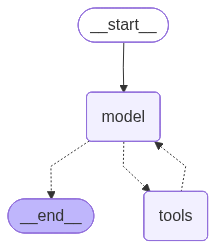

In [11]:
from IPython.display import Image, display

# Generate the graph PNG and display it
# Use xray=True to show internal node details
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Messages

In [13]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# Using message objects
messages = [
    SystemMessage("You are a pirate. Always respond in pirate speak always with one sentence."),
    HumanMessage("What is machine learning?"),
]

response = llm.invoke(messages)
print(response.content)

It be when a computer learns from a chest o' data, aye, without a landlubber tellin' it every single step!


In [14]:
# Equivalent dict format (OpenAI-compatible)
response = model.invoke([
    {"role": "system", "content": "You are a pirate. Always respond in pirate speak."},
    {"role": "user", "content": "What is machine learning?"},
])
print(response.content)

Ahoy there, matey! Ye be askin' 'bout machine learnin', eh? That's a grand question, fit for a wise old salt!

Imagine yer trusty ship's logbook, but instead o' *you* writin' down every single order and every single observation, ye teach the logbook itself to *learn*!

Ye feed this 'machine' (be it a fancy compass or a smart spyglass) with mountains o' old maps, o' weather charts from a thousand voyages, o' records o' where the treasure was found or where the kraken dwells.

The 'machine' then starts to spot the patterns! It figures out which winds bring storms, which islands hold the gold, or which sails belong to a friendly fleet versus a rival pirate gang, all by itself!

It ain't just followin' yer direct commands, see? It's usin' all that past experience, all that 'data,' to make its *own* predictions and steer a course, or tell ye where to dig, or warn ye o' a coming squall. It learns to be smart, like a seasoned old tar who knows the sea without needin' a captain's every single 

In [15]:
# Multi-turn conversation
conversation = [
    SystemMessage("You translate English to French."),
    HumanMessage("I love programming."),
    AIMessage("J'adore la programmation."),
    HumanMessage("I love building AI applications."),
]
response = model.invoke(conversation)
print(response.content)

J'adore développer des applications d'IA.


In [16]:
# AIMessage metadata — token usage
response = model.invoke("Hello!")
print(f"Content: {response.content}")
print(f"Type: {response.type}")
print(f"Token usage: {response.usage_metadata}")

Content: Hello there! How can I help you today?
Type: ai
Token usage: {'input_tokens': 3, 'output_tokens': 22, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 12}}


# Tools

In [17]:
from langchain_core.tools import tool

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression.

    Args:
        expression: A Python math expression like '2 + 2' or '3 ** 4'
    """
    import math
    return str(eval(expression))

# Inspect the tool
print(f"Name: {calculate.name}")
print(f"Description: {calculate.description}")
print(f"Schema: {calculate.args_schema.model_json_schema()}")

Name: calculate
Description: Evaluate a mathematical expression.

    Args:
        expression: A Python math expression like '2 + 2' or '3 ** 4'
Schema: {'description': "Evaluate a mathematical expression.\n\nArgs:\n    expression: A Python math expression like '2 + 2' or '3 ** 4'", 'properties': {'expression': {'title': 'Expression', 'type': 'string'}}, 'required': ['expression'], 'title': 'calculate', 'type': 'object'}


In [22]:
# I want to create an agent that reads and writes to files
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.tools import tool

@tool
def read_file(file_path: str) -> str:
    """Read a file and return its content."""
    with open(file_path, "r") as file:
        return file.read()

@tool
def write_file(file_path: str, content: str) -> str:
    """Write to a file."""
    with open(file_path, "w") as file:
        file.write(content)
    return "File written successfully."

api_key = userdata.get("GEMINI_API_KEY")

model = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)
agent = create_agent(
    model=model,
    tools=[read_file, write_file],
    system_prompt="You are a helpful assistant that can read and write to file.",
)

for chunk in agent.stream(
    {"messages": """Create a new file called 'research.md'
                       summarize the latest langchain version starting with the package number."""},
    stream_mode="values",
):
    print(chunk["messages"][-1].pretty_print())

================================ Human Message =================================

Create a new file called 'research.md'
                       summarize the latest langchain version starting with the package number.
None
================================== Ai Message ==================================
Tool Calls:
  write_file (8bbbed8b-842a-4020-b632-f945bd09c8c2)
 Call ID: 8bbbed8b-842a-4020-b632-f945bd09c8c2
  Args:
    file_path: research.md
    content: Langchain Version [Please insert the latest package number here, e.g., 0.1.0]: Langchain continues to advance as a framework for developing applications powered by large language models. Recent updates have likely focused on enhancing agent capabilities, improving integrations with various LLMs and external tools, and refining prompt engineering techniques. Key areas of development often include performance optimizations, new chain types, and expanded support for different data sources and output formats. Please refer to the officia

# Dependency Injection with context_schema

In [24]:
from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime

@dataclass
class UserContext:
    user_name: str
    role: str

USER_DB = {
    "alice": {"balance": 5000, "plan": "premium"},
    "bob": {"balance": 120, "plan": "free"},
}

@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    name = runtime.context.user_name
    info = USER_DB.get(name, {})
    return f"User: {name} | Balance: ${info.get('balance')} | Plan: {info.get('plan')}"



api_key = userdata.get("GEMINI_API_KEY")

model = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)
agent = create_agent(
     model=model,
     tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You help users check their account information.",
 )

# Inject different user contexts at runtime
result = agent.invoke(
    {"messages": "What's my name and account balance?"},
     context=UserContext(user_name="alice", role="admin"),
 )

result

result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is alice and your account balance is $5000.


# Short-Term Memory

In [27]:
from langgraph.checkpoint.memory import InMemorySaver


@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

api_key = userdata.get("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(
    temperature=0.9,
    model="gemini-2.5-flash",
    google_api_key=api_key
)

agent_with_memory = create_agent(
    model=model,
    tools=[add],
    system_prompt="You are a helpful assistant. Remember details from our conversation.",
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "session-1"}}

In [28]:
# First message
result = agent_with_memory.invoke(
    {"messages": "Hi! My name is John and I'm a data scientist."},
    config,
)
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello John, nice to meet you! Is there anything I can help you with today? I can add two numbers if you want to try that out.


In [29]:
# Follow-up — the agent remembers!
result = agent_with_memory.invoke(
    {"messages": "What is my name and what do I do?"},
    config,
)
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is John and you are a data scientist.


In [30]:
# Different thread = different memory (no knowledge of John)
config_2 = {"configurable": {"thread_id": "session-2"}}

result = agent_with_memory.invoke(
    {"messages": "What is my name?"},
    config_2,
)
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

I don't know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past interactions. Is there anything else I can do to help?


In [32]:
# Continue the original conversation (session-1)
result = agent_with_memory.invoke(
    {"messages": "add 2 and 5"},
    config,  # back to session-1
)
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

The sum of 2 and 5 is 7.


# Steraming
Three stream modes for different use cases:

| Mode | Output | Use Case |
|------|--------|----------|
| `values` | Full state after each step | Track agent reasoning |
| `messages` | (token, metadata) tuples | Real-time chatbot UX |
| `custom` | User-defined data | Progress updates from tools |


In [33]:
# Mode 1: "values" — see each agent step
for step in agent_with_memory.stream(
    {"messages": "What is the capital of Portugal?"},
    config,
    stream_mode="values",
):
    step["messages"][-1].pretty_print()
    print("---")

================================ Human Message =================================

What is the capital of Portugal?
---


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 44.666869177s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
# Mode 2: "messages" — token by token (ideal for chatbot UX)
for token, metadata in agent_with_memory.stream(
    {"messages": "Write a short poem about AI agents"},
    config,
    stream_mode="messages",
):
    if token.content:
        print(token.content, end="", flush=True)

In [ ]:
# Mode 3: "custom" — progress updates from inside tools
from langgraph.config import get_stream_writer
import time

@tool
def research_topic(query: str) -> str:
    """Research a topic with progress updates."""
    writer = get_stream_writer()
    writer({"status": "Searching for information..."})
    time.sleep(1)
    writer({"status": "Analyzing results..."})
    time.sleep(1)
    return f"Research complete: found 5 relevant articles about '{query}'"

streaming_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[research_topic],
)

for chunk in streaming_agent.stream(
    {"messages": "Research the state of LLM agents in 2026"},
    stream_mode=["values", "custom"],
):
    print(chunk)